# 01_eda.ipynb - Análisis Exploratorio de Datos (EDA)

**Objetivo**: Entender los datos, validar calidad, explorar features y distribución de variables.

**NO hace backtest ni genera señales**. Eso corresponde a fases posteriores.

Flujo del proyecto:
1. **01_eda.ipynb** ← ESTE: EDA puro
2. **batch_calibrate.py** → calibra Csl + BP → `data/universe_admitted.csv`
3. **02_strategy_generator.ipynb** → Generador de estrategias (pendiente)
4. **03_backtest_strategies.ipynb** → Backtest de estrategias generadas
5. **04_robustez.ipynb** → Tests de robustez (Sección 9)
6. **05_validacion.ipynb** → Validación final (Sección 10)

## 1. Imports y Configuración

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from config.settings import DATA, FEATURES, RISK, get_universe_tickers
from src.data import load_ohlc_from_yfinance, validate_ohlc_data
from src.features import add_all_features, calculate_efficiency_ratio

print(f"Config: {DATA.source} {DATA.interval} {DATA.period}")
print(f"Universe tickers: {len(get_universe_tickers())}")

Config: yfinance 1h 730d
Universe tickers: 22


## 2. Cargar Universo Admitido (Csl + BP ya calibrados)

In [2]:
admitted_path = REPO_ROOT / "data" / "universe_admitted.csv"
admitted_df = pd.read_csv(admitted_path)
print(f"Activos admitidos (pasan Csl + BP): {len(admitted_df)}")
admitted_df

Activos admitidos (pasan Csl + BP): 9


,ticker,csl,bp_median,bp_max,n_samples
0,MCRB,2.073369,1648.271631,2910.751651,500
1,LRMR,2.186679,1735.008416,2948.322504,500
2,ABSI,2.297152,1530.309591,2674.816278,500
3,IMUX,2.348268,1550.750121,2791.049794,500
4,KPTI,2.387959,1318.524144,2546.854384,500
5,HBIO,2.413816,1507.814490,2619.348096,500
6,HOTH,2.462243,1478.604231,2582.297380,500
7,SGMO,2.540506,915.892752,1721.758859,500
8,EBON,2.746795,1192.554669,1985.683930,500


## 3. EDA por Activo: Calidad de Datos + Features

In [3]:
eda_results = []

for _, row in admitted_df.iterrows():
    ticker = row['ticker']
    csl = row['csl']
    
    print(f"\n=== {ticker} (Csl={csl:.3f}) ===")
    
    try:
        df = load_ohlc_from_yfinance(ticker, period=DATA.period, interval=DATA.interval)
        
        if not validate_ohlc_data(df, min_rows=FEATURES.atr_period + 100):
            print(f"  ❌ Datos insuficientes: {len(df)} barras")
            continue
        
        # Features
        df = add_all_features(
            df,
            atr_period=FEATURES.atr_period,
            sma_period=FEATURES.sma_period,
            roc_period=FEATURES.roc_period
        )
        
        # Estadísticas básicas
        price_stats = df['Close'].describe()
        atr_stats = df['ATR_50'].dropna().describe()
        er = calculate_efficiency_ratio(df, k=FEATURES.er_k)
        er_stats = er.dropna().describe()
        
        n_bars = len(df)
        date_range = f"{df['Datetime'].iloc[0].date()} a {df['Datetime'].iloc[-1].date()}"
        
        print(f"  Barras: {n_bars} ({date_range})")
        print(f"  Precio: ${price_stats['mean']:.2f} ± ${price_stats['std']:.2f}")
        print(f"  ATR(50): {atr_stats['mean']:.4f} ± {atr_stats['std']:.4f}")
        print(f"  ER(10): {er_stats['mean']:.3f} ± {er_stats['std']:.3f} (>{FEATURES.er_threshold}: {(er > FEATURES.er_threshold).mean():.1%})")
        
        eda_results.append({
            'ticker': ticker,
            'csl': csl,
            'n_bars': n_bars,
            'price_mean': price_stats['mean'],
            'price_std': price_stats['std'],
            'atr_mean': atr_stats['mean'],
            'atr_std': atr_stats['std'],
            'er_mean': er_stats['mean'],
            'er_std': er_stats['std'],
            'er_above_thresh_pct': (er > FEATURES.er_threshold).mean()
        })
        
    except Exception as e:
        print(f"  ❌ Error: {e}")
        continue


=== MCRB (Csl=2.073) ===
  Barras: 5049 (2023-07-31 a 2026-06-26)
  Precio: $19.54 ± $14.47
  ATR(50): 0.6349 ± 0.4531
  ER(10): -0.047 ± 0.406 (>0.3: 20.4%)

=== LRMR (Csl=2.187) ===
  Barras: 5073 (2023-07-31 a 2026-06-26)
  Precio: $4.92 ± $2.27
  ATR(50): 0.1376 ± 0.0831
  ER(10): -0.029 ± 0.420 (>0.3: 23.8%)

=== ABSI (Csl=2.297) ===
  Barras: 5073 (2023-07-31 a 2026-06-26)
  Precio: $3.49 ± $1.29
  ATR(50): 0.1031 ± 0.0529
  ER(10): -0.000 ± 0.417 (>0.3: 26.2%)

=== IMUX (Csl=2.348) ===
  Barras: 5073 (2023-07-31 a 2026-06-26)
  Precio: $11.45 ± $2.92
  ATR(50): 0.3149 ± 0.1062
  ER(10): -0.026 ± 0.406 (>0.3: 22.7%)

=== KPTI (Csl=2.388) ===
  Barras: 5070 (2023-07-31 a 2026-06-26)
  Precio: $11.04 ± $5.35
  ATR(50): 0.3564 ± 0.2161
  ER(10): -0.038 ± 0.404 (>0.3: 21.1%)

=== HBIO (Csl=2.414) ===
  Barras: 5019 (2023-07-31 a 2026-06-26)
  Precio: $21.32 ± $16.48
  ATR(50): 0.4337 ± 0.2922
  ER(10): -0.058 ± 0.391 (>0.3: 19.0%)

=== HOTH (Csl=2.462) ===
  Barras: 4812 (2023-07-31

## 4. Resumen EDA Consolidado

In [4]:
if eda_results:
    eda_df = pd.DataFrame(eda_results)
    
    # Guardar
    out_dir = REPO_ROOT / "data"
    eda_df.to_csv(out_dir / "eda_summary.csv", index=False)
    
    print("\n=== RESUMEN EDA ===")
    print(eda_df[['ticker', 'csl', 'n_bars', 'price_mean', 'atr_mean', 'er_mean', 'er_above_thresh_pct']].to_string(index=False))
    
    # Stats agregadas
    print(f"\nTotal activos: {len(eda_df)}")
    print(f"Barras totales: {eda_df['n_bars'].sum():,}")
    print(f"Precio promedio: ${eda_df['price_mean'].mean():.2f}")
    print(f"ATR promedio: {eda_df['atr_mean'].mean():.4f}")
    print(f"ER promedio: {eda_df['er_mean'].mean():.3f}")
    print(f"% barras ER>0.3: {eda_df['er_above_thresh_pct'].mean():.1%}")
    
    eda_df
else:
    print("❌ Sin resultados EDA")


=== RESUMEN EDA ===
ticker      csl  n_bars  price_mean  atr_mean   er_mean  er_above_thresh_pct
  MCRB 2.073369    5049   19.541518  0.634863 -0.047500             0.204199
  LRMR 2.186679    5073    4.922284  0.137568 -0.028601             0.237729
  ABSI 2.297152    5073    3.489383  0.103148 -0.000229             0.261778
  IMUX 2.348268    5073   11.452015  0.314945 -0.025811             0.226690
  KPTI 2.387959    5070   11.041966  0.356369 -0.037710             0.210848
  HBIO 2.413816    5019   21.323729  0.433730 -0.058048             0.190277
  HOTH 2.462243    4812    1.169560  0.039348 -0.045179             0.158770
  SGMO 2.540506    5038    0.713187  0.029976 -0.058110             0.209805
  EBON 2.746795    3570    6.174323  0.213614 -0.042215             0.119608

Total activos: 9
Barras totales: 43,777
Precio promedio: $8.87
ATR promedio: 0.2515
ER promedio: -0.038
% barras ER>0.3: 20.2%


## 5. Visualizaciones Rápidas (Opcional)

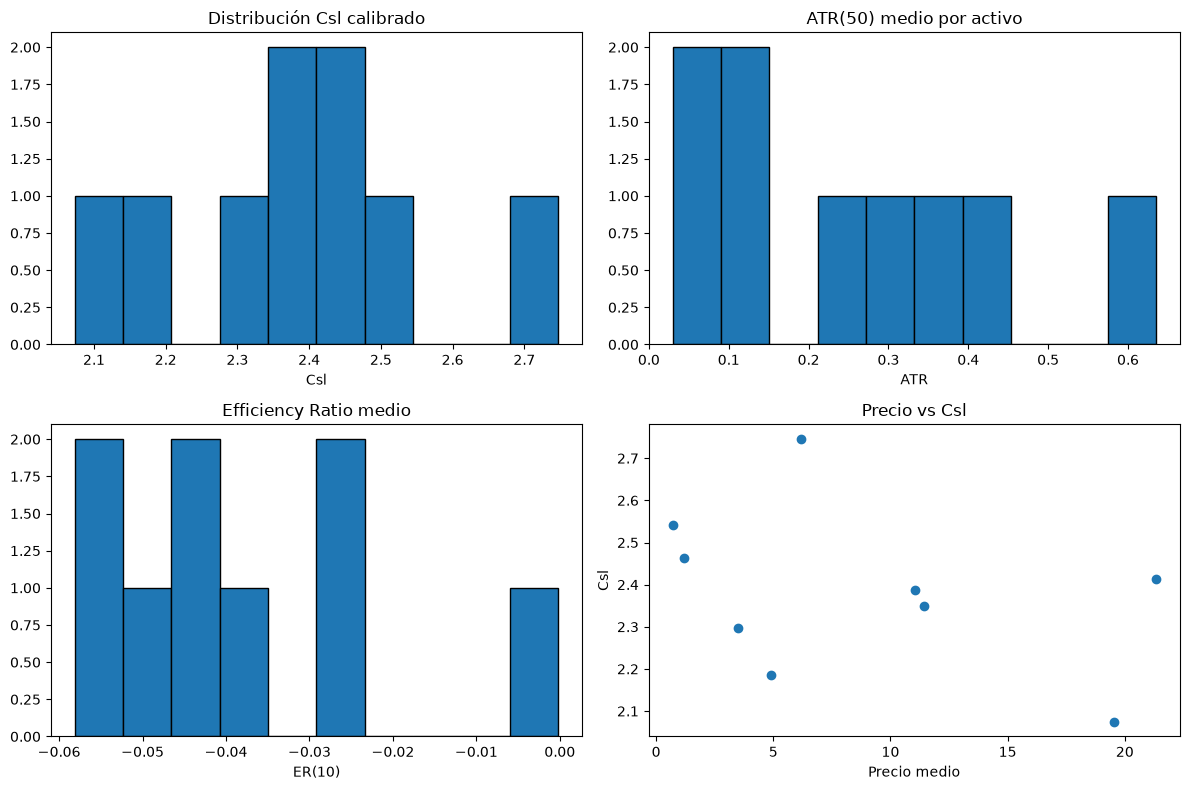

In [5]:
if eda_results:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Distribución Csl
    axes[0,0].hist(eda_df['csl'], bins=10, edgecolor='black')
    axes[0,0].set_title('Distribución Csl calibrado')
    axes[0,0].set_xlabel('Csl')
    
    # Distribución ATR medio
    axes[0,1].hist(eda_df['atr_mean'], bins=10, edgecolor='black')
    axes[0,1].set_title('ATR(50) medio por activo')
    axes[0,1].set_xlabel('ATR')
    
    # ER medio
    axes[1,0].hist(eda_df['er_mean'], bins=10, edgecolor='black')
    axes[1,0].set_title('Efficiency Ratio medio')
    axes[1,0].set_xlabel('ER(10)')
    
    # Precio vs Csl
    axes[1,1].scatter(eda_df['price_mean'], eda_df['csl'])
    axes[1,1].set_xlabel('Precio medio')
    axes[1,1].set_ylabel('Csl')
    axes[1,1].set_title('Precio vs Csl')
    
    plt.tight_layout()
    plt.savefig(out_dir / "eda_plots.png", dpi=150)
    plt.show()